In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import os
import numpy as np

In [2]:
path = ("/common/home/lh811/Documents/ML_Pricing/data/aggregate_model_performance")

dfs = {}

for file in os.listdir(path):
    joined = os.path.join(path, file)
    dfs[file] = pd.read_csv(joined)

for key, file in dfs.items():
    print(file.head())

    permno        DATE      true        rf
0  92460.0  2015-02-27  0.138996  0.002982
1  16555.0  2015-02-27  0.192978  0.004348
2  32791.0  2015-02-27  0.228461  0.002782
3  72119.0  2015-02-27 -0.011737  0.002987
4  14344.0  2015-02-27  0.532283  0.001248
    permno        DATE      true       ols      olsh
0  92460.0  2015-02-27  0.138996 -0.003755 -0.005315
1  16555.0  2015-02-27  0.192978  0.011232  0.010538
2  32791.0  2015-02-27  0.228461 -0.004021 -0.004443
3  72119.0  2015-02-27 -0.011737 -0.009626 -0.010388
4  14344.0  2015-02-27  0.532283 -0.004471 -0.005762
    permno        DATE      true        en       enh
0  92460.0  2015-02-27  0.138996 -0.003504 -0.004577
1  16555.0  2015-02-27  0.192978 -0.001671 -0.001335
2  32791.0  2015-02-27  0.228461 -0.010523 -0.010732
3  72119.0  2015-02-27 -0.011737 -0.012452 -0.012759
4  14344.0  2015-02-27  0.532283 -0.014220 -0.015190
    permno        DATE      true       pcr
0  92460.0  2015-02-27  0.138996  0.003710
1  16555.0  2015-02-

In [3]:
def monthly_r2(df_dict):

    results = {}
    for key, val in df_dict.items():
        # Case 1: dataframe has a model column
        if "model" in val.columns:

            for model, filt in val.groupby("model"):
                sse = np.sum((filt["true"] - filt["pred"])**2)
                sst = np.sum(filt["true"]**2)
                results[model] =  100*(1 - (sse / sst))

        # Case 2: each prediction column is a model
        else:
            pred_cols = [c for c in val.columns if c not in ["true", "DATE", "permno", "Unnamed: 0"]]
            true = val["true"]
            sst = np.sum((true)**2)
            for col in pred_cols:
                sse = np.sum((true - val[col])**2)
                results[col] = 100*(1 - (sse / sst))



    return results

In [4]:
def monthly_r2_fixed(df_dict):

    results = {}

    for _, df in df_dict.items():

        # -------------------------
        # CASE 1: long format
        # -------------------------
        if "model" in df.columns:

            for model, g in df.groupby("model"):

                y = g["true"].values
                yhat = g["pred"].values

                sse = np.sum((y - yhat) ** 2)
                sst = np.sum(y ** 2)

                if model not in results:
                    results[model] = {"sse": 0.0, "sst": 0.0}

                results[model]["sse"] += sse
                results[model]["sst"] += sst

        # -------------------------
        # CASE 2: wide format
        # -------------------------
        else:

            pred_cols = [
                c for c in df.columns
                if c not in ["true", "DATE", "permno", "Unnamed: 0"]
            ]

            y = df["true"].values
            y2 = np.sum(y ** 2)

            for col in pred_cols:

                yhat = df[col].values
                sse = np.sum((y - yhat) ** 2)

                if col not in results:
                    results[col] = {"sse": 0.0, "sst": 0.0}

                results[col]["sse"] += sse
                results[col]["sst"] += y2

    # -------------------------
    # FINAL R^2 computation
    # -------------------------
    final_r2 = {
        model: 100 * (1 - v["sse"] / v["sst"])
        for model, v in results.items()
    }

    return final_r2

In [5]:
monthly_results = monthly_r2(dfs)

In [6]:
monthly_results

{'rf': np.float64(0.3315486270432211),
 'ols': np.float64(-0.005521103254935156),
 'olsh': np.float64(-0.002116158909570842),
 'en': np.float64(0.05490367212971359),
 'enh': np.float64(0.07166448024643612),
 'pcr': np.float64(0.25204848979042405),
 'tree': np.float64(0.1859107807433369),
 'treeh': np.float64(0.059730908908495195),
 'nn1': np.float64(0.12122778755273567),
 'nn2': np.float64(0.06885743948968903),
 'nn3': np.float64(0.14908223006403487),
 'nn4': np.float64(0.296065981476179),
 'nn5': np.float64(0.19917995256293342)}

In [7]:
monthly_df = pd.DataFrame(monthly_results.items(), columns = ['model', 'r2_oos'])

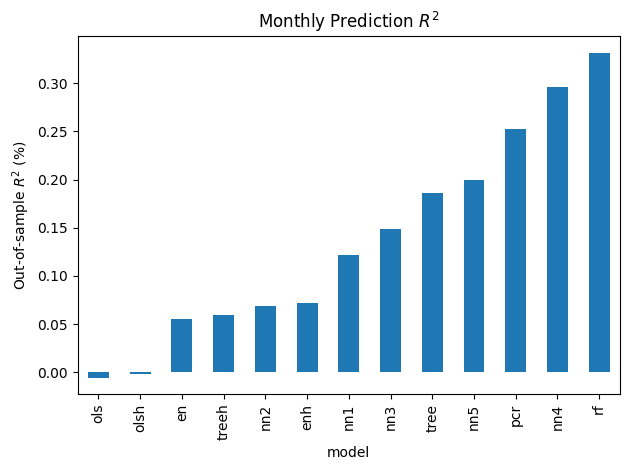

In [10]:
monthly_df.sort_values('r2_oos').plot(
    x='model',
    y='r2_oos',
    kind='bar',
    legend=False
)

plt.title('Monthly Prediction $R^2$')
plt.ylabel('Out-of-sample $R^2$ (%)')
plt.tight_layout()
plt.savefig('/common/home/lh811/Documents/ML_Pricing/data/monthly_r2_all')
plt.show()